<a href="https://colab.research.google.com/github/Akshatha-Gadasandula/DL_LAB/blob/main/WEEK10-11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

week- **10**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.9464 - loss: 0.1831
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.9827 - loss: 0.0595


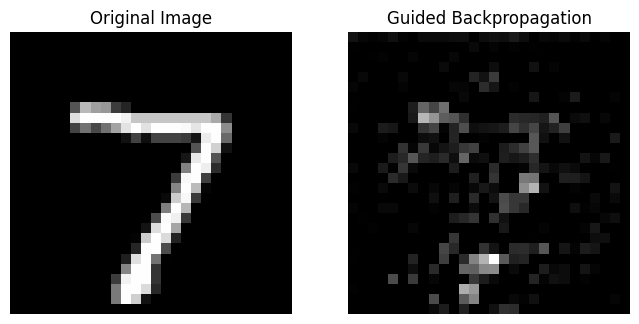

In [ ]:
# 3.Guided Backpropagation on MNIST
# Discover which input pixels influence prediction

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

# --------------------------
# Load MNIST
# --------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# --------------------------
# Simple CNN Model
# --------------------------
model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=2, batch_size=64)

# --------------------------
# Select One Test Image
# --------------------------
img = tf.convert_to_tensor(x_test[0:1])

# --------------------------
# Guided Backpropagation
# --------------------------
with tf.GradientTape() as tape:
    tape.watch(img)
    pred = model(img)
    class_idx = tf.argmax(pred[0])
    loss = pred[:, class_idx]

grads = tape.gradient(loss, img)

# keep only positive gradients
guided_grads = tf.maximum(grads, 0)

# --------------------------
# Display Results
# --------------------------
plt.figure(figsize=(8,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Guided Backpropagation Map
plt.subplot(1,2,2)
plt.imshow(guided_grads[0].numpy().reshape(28,28), cmap='gray')
plt.title("Guided Backpropagation")
plt.axis("off")

plt.show()

week -**11**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2523 - val_loss: 0.1708
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1535 - val_loss: 0.1384
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1332 - val_loss: 0.1257
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1237 - val_loss: 0.1194
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1190 - val_loss: 0.1154
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


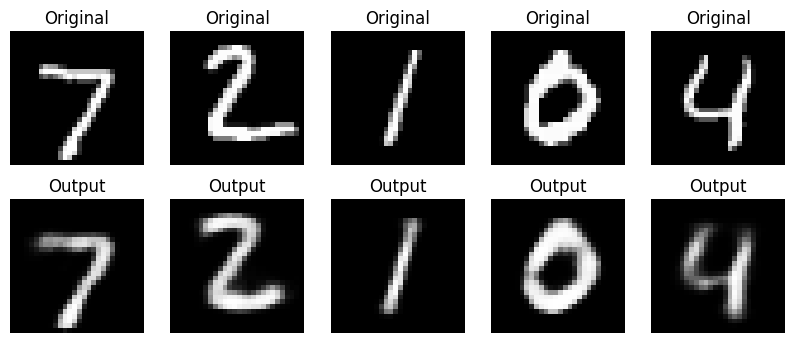

In [ ]:
# Simple AutoEncoder on MNIST Dataset

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 -> 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
autoencoder.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)
decoded_imgs = autoencoder.predict(x_test)

plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Output")
    plt.axis("off")

plt.show()

Training Undercomplete AE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2372 - val_loss: 0.1559
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1371 - val_loss: 0.1216
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1170 - val_loss: 0.1102
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1086 - val_loss: 0.1051
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1035 - val_loss: 0.1000
Training Overcomplete AE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1388 - val_loss: 0.0841
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0791 - val_loss: 0.0745
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0731 - val_loss: 0.0712
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0706 - val_loss: 0.0695
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0691 - val_loss: 0.0684
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


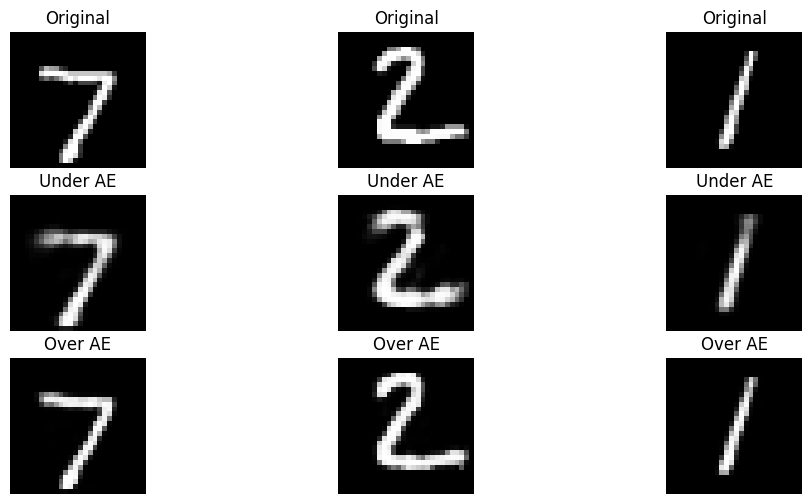

In [ ]:
# Undercomplete AE and Overcomplete AE on MNIST

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
latent = Dense(32, activation='relu')(encoded)   # smaller → undercomplete

# Decoder
decoded = Dense(128, activation='relu')(latent)
output_layer = Dense(784, activation='sigmoid')(decoded)

undercomplete_ae = Model(input_layer, output_layer)

undercomplete_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Training Undercomplete AE")

undercomplete_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

input_layer2 = Input(shape=(784,))

# Encoder
encoded2 = Dense(1024, activation='relu')(input_layer2)
latent2 = Dense(900, activation='relu')(encoded2)   # larger → overcomplete

# Decoder
decoded2 = Dense(1024, activation='relu')(latent2)
output_layer2 = Dense(784, activation='sigmoid')(decoded2)

overcomplete_ae = Model(input_layer2, output_layer2)

overcomplete_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Training Overcomplete AE")

overcomplete_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

under_output = undercomplete_ae.predict(x_test)
over_output = overcomplete_ae.predict(x_test)

plt.figure(figsize=(12,6))

for i in range(3):
    # Original
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Undercomplete
    plt.subplot(3, 3, i + 4)
    plt.imshow(under_output[i].reshape(28,28), cmap='gray')
    plt.title("Under AE")
    plt.axis("off")

    # Overcomplete
    plt.subplot(3, 3, i + 7)
    plt.imshow(over_output[i].reshape(28,28), cmap='gray')
    plt.title("Over AE")
    plt.axis("off")

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3100 - val_loss: 0.1990
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1883 - val_loss: 0.1760
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1706 - val_loss: 0.1648
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1626 - val_loss: 0.1581
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1578 - val_loss: 0.1546
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


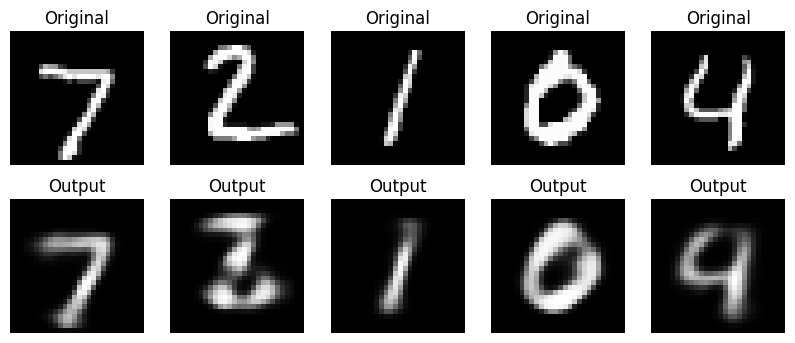

In [ ]:
# Regularization in AutoEncoder (L2 Regularization) on MNIST

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# AutoEncoder with Regularization
input_layer = Input(shape=(784,))

# Encoder with L2 Regularization
encoded = Dense(
    128,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(input_layer)

latent = Dense(
    32,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(encoded)

# Decoder
decoded = Dense(128, activation='relu')(latent)
output_layer = Dense(784, activation='sigmoid')(decoded)

regularized_ae = Model(input_layer, output_layer)

# -------------------------
# Compile
# -------------------------
regularized_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Train
regularized_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Predict
decoded_imgs = regularized_ae.predict(x_test)
# Display Results
plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Output")
    plt.axis("off")

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2542 - val_loss: 0.1871
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1733 - val_loss: 0.1622
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1575 - val_loss: 0.1519
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1498 - val_loss: 0.1460
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1449 - val_loss: 0.1416
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


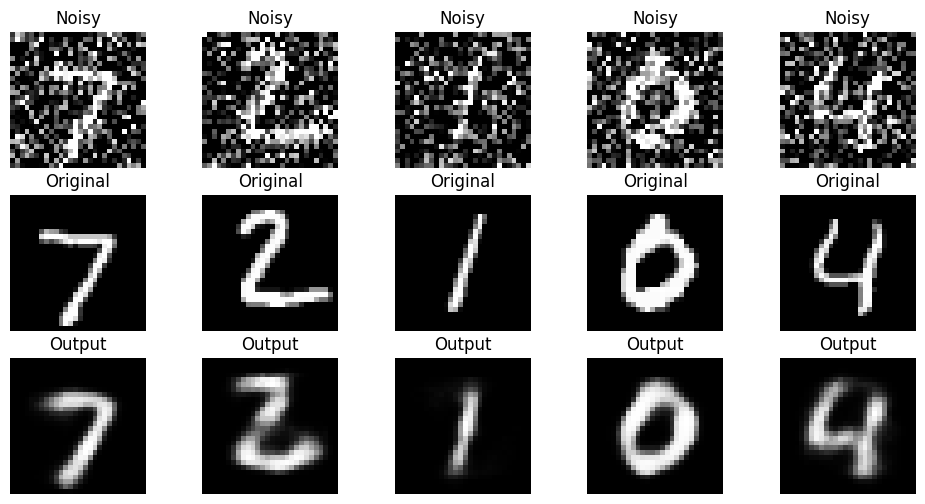

In [ ]:
#Denoising AutoEncoder on MNIST

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
# Load MNIST

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Add Noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0., 1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, 0., 1.)

# Denoising AutoEncoder
input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
latent = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(latent)
output_layer = Dense(784, activation='sigmoid')(decoded)

dae = Model(input_layer, output_layer)
# Compile

dae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)


# Train
# input = noisy image
# output = original clean image

dae.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)
denoised_imgs = dae.predict(x_test_noisy)


plt.figure(figsize=(12,6))

for i in range(5):
    # Noisy Image
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test_noisy[i].numpy().reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Original Image
    plt.subplot(3, 5, i + 6)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Denoised Output
    plt.subplot(3, 5, i + 11)
    plt.imshow(denoised_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Output")
    plt.axis("off")

plt.show()

PCA Output Shape: (10000, 32)
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2304 - val_loss: 0.1527
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1337 - val_loss: 0.1202
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1162 - val_loss: 0.1097
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1080 - val_loss: 0.1034
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1028 - val_loss: 0.0994
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AE Output Shape: (10000, 32)


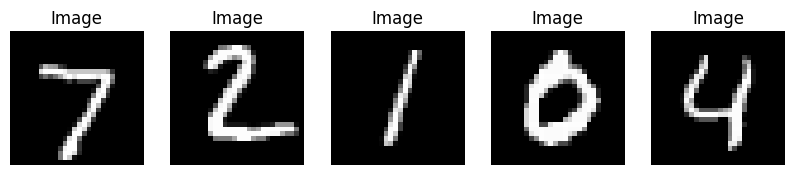


PCA reduces data using linear compression
AutoEncoder reduces data using non-linear compression


In [ ]:
# PCA with AutoEncoder on MNIST

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from sklearn.decomposition import PCA

# Load MNIST
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# PCA
pca = PCA(n_components=32)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

print("PCA Output Shape:", x_test_pca.shape)

input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
latent = Dense(32, activation='relu')(encoded)   # same as PCA components

# Decoder
decoded = Dense(128, activation='relu')(latent)
output_layer = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
autoencoder.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Encoder model only
encoder = Model(input_layer, latent)

x_test_ae = encoder.predict(x_test)

print("AE Output Shape:", x_test_ae.shape)

# Display Comparison
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Image")
    plt.axis("off")

plt.show()

print("\nPCA reduces data using linear compression")
print("AutoEncoder reduces data using non-linear compression")

Training Sparse AE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.4126 - val_loss: 0.2689
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2657 - val_loss: 0.2638
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2637 - val_loss: 0.2631
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2631 - val_loss: 0.2627
Training Contractive AE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3087 - val_loss: 0.1966
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1824 - val_loss: 0.1695
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1658 - val_loss: 0.1601
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1594 - val_loss: 0.1558
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1557 - val_loss: 0.1528
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


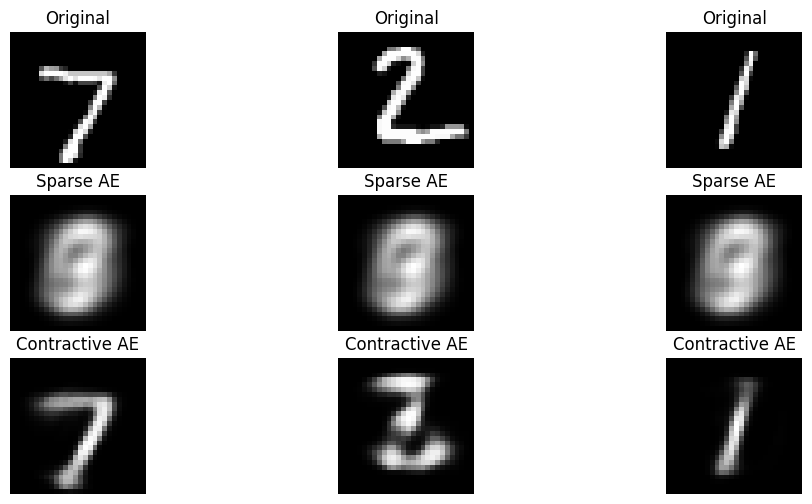

In [ ]:
# Sparse AE and Contractive AE on MNIST

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras import regularizers

# Load MNIST
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 1. Sparse AutoEncoder

input_layer = Input(shape=(784,))

# L1 regularization → sparsity
encoded = Dense(
    128,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-4)
)(input_layer)

latent = Dense(
    32,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-4)
)(encoded)

decoded = Dense(128, activation='relu')(latent)
output_layer = Dense(784, activation='sigmoid')(decoded)

sparse_ae = Model(input_layer, output_layer)

sparse_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Training Sparse AE")

sparse_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)
# 2. Contractive AutoEncoder
# (simple version using strong L2 regularization)

input_layer2 = Input(shape=(784,))

encoded2 = Dense(
    128,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)(input_layer2)

latent2 = Dense(
    32,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)(encoded2)

decoded2 = Dense(128, activation='relu')(latent2)
output_layer2 = Dense(784, activation='sigmoid')(decoded2)

contractive_ae = Model(input_layer2, output_layer2)

contractive_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Training Contractive AE")

contractive_ae.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Prediction

sparse_output = sparse_ae.predict(x_test)
contractive_output = contractive_ae.predict(x_test)

plt.figure(figsize=(12,6))

for i in range(3):
    # Original
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Sparse AE
    plt.subplot(3, 3, i + 4)
    plt.imshow(sparse_output[i].reshape(28,28), cmap='gray')
    plt.title("Sparse AE")
    plt.axis("off")

    # Contractive AE
    plt.subplot(3, 3, i + 7)
    plt.imshow(contractive_output[i].reshape(28,28), cmap='gray')
    plt.title("Contractive AE")
    plt.axis("off")

plt.show()